# Marco Geoestadistico


In [81]:
import yarl 
import requests
from scripts.download import download
from scripts.config import DATA_FOLDERS, get_project_root
from zipfile import ZipFile
import os

raw_data = DATA_FOLDERS['raw'] / "inegi"
ext_data = DATA_FOLDERS['external'] / "inegi"

mexico_map = "https://www.inegi.org.mx/contenidos/productos/prod_serv/contenidos/espanol/bvinegi/productos/geografia/marcogeo/794551196649/mg_integrado_encuesta_intercensal_2025.zip"
MEXICO_URL = yarl.URL(mexico_map)
if not os.path.exists(get_project_root() / "docs" / "mexico_agro.zip"):
    check_mexicomap = requests.get(MEXICO_URL)
    if check_mexicomap.status_code==200:
            download(yarl.URL(MEXICO_URL), "Mexico.zip", ext_data)
            with ZipFile(ext_data / "Mexico.zip", "r") as mexico:
                mexico.extractall(ext_data)


In [82]:


url = MEXICO_URL
output = ext_data / "Mexico.zip"

chunk_size = 4 * 1024 * 1024  # 4 MB

downloaded = output.stat().st_size if output.exists() else 0

headers = {}

if downloaded:
    headers["Range"] = f"bytes={downloaded}-"

with requests.get(
    url,
    headers=headers,
    stream=True,
    timeout=(10, 120),
) as response:

    # 206 = servidor aceptó Range
    # 200 = descarga completa normal
    if downloaded and response.status_code != 206:
        print("El servidor no soportó reanudación.")
        downloaded = 0
        mode = "wb"
    else:
        mode = "ab" if downloaded else "wb"

    response.raise_for_status()

    remaining = int(response.headers.get("content-length", 0))
    total = downloaded + remaining

    with open(output, mode) as f:
        for chunk in response.iter_content(chunk_size=chunk_size):
            if not chunk:
                continue

            f.write(chunk)
            downloaded += len(chunk)

            if total:
                print(
                    f"\r{downloaded / 1024**3:.2f} / "
                    f"{total / 1024**3:.2f} GB "
                    f"({100 * downloaded / total:.1f}%)",
                    end="",
                )

print("\nDescarga terminada.")

0.05 / 0.24 GB (19.3%)

KeyboardInterrupt: 

# Censo Agropecuario 2022

In [1]:
from scripts.config import file_to
import requests
from bs4 import BeautifulSoup
from io import BytesIO
from zipfile import ZipFile
import yarl
import os
from scripts.download import download

inegi_ca = yarl.URL("https://www.inegi.org.mx/contenidos/programas/")
files = ["cagf/2007/datosabiertos/cagf2007_csv.zip"] + [f"ca/2022/datosabiertos/{file}" 
for file in ("ca_2022_superficie_csv.zip", "ca_2022_upagro_csv.zip", "ca_2022_upfores_csv.zip")]

for f in files:
    file_name = f.split("/")[-1]
    download(inegi_ca / f, file_name, file_to("raw","inegi"))


https://www.inegi.org.mx/contenidos/programas/cagf/2007/datosabiertos/cagf2007_csv.zip cagf2007_csv.zip /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/cagf2007_csv.zip
El archivo ya fue descargado. Se encuentra en /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/cagf2007_csv.zip
https://www.inegi.org.mx/contenidos/programas/ca/2022/datosabiertos/ca_2022_superficie_csv.zip ca_2022_superficie_csv.zip /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/ca_2022_superficie_csv.zip
El archivo ya fue descargado. Se encuentra en /home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/ca_2022_superficie_csv.zip
https://www.inegi.org.mx/contenidos/programas/ca/2022/datosabiertos/ca_2022_upagro_csv.zip ca_2022_upagro_csv.zip /home/

In [2]:
inegi_files= os.listdir(file_to("raw", "inegi"))

for igf in inegi_files:
    zipd = file_to("raw", "inegi") / igf
    fext = igf.split(".")[1]
    name = igf.split(".")[0].rstrip("_csv")
    print(zipd)
    with ZipFile(zipd, "r") as fz:
        fz.extractall(file_to("external", "inegi") / f"{name}")

/home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/cagf2007_csv.zip
/home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/ca_2022_superficie_csv.zip
/home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/ca_2022_upagro_csv.zip
/home/david/Documents/Repositories/academica/proyecto_agronomia/data/raw/inegi/ca_2022_upfores_csv.zip


In [12]:
import pandas as pd

folders = os.listdir(file_to("external","inegi"))
print(folders)
folder = folders[1]
print(folder)
files = os.listdir(file_to("external","inegi") / folder / "conjunto_datos")

from scripts.preparation import get_encoding
# get_encoding(file_to("external","inegi") / folder / "conjunto_datos" / "indice_superficie.csv")

# data = pd.read_csv(file_to("external","inegi") / folder / "conjunto_datos" / "indice_superficie.csv")
dic = pd.read_csv(file_to("external","inegi") / folder / "diccionario_datos" / "diccionario_de_datos_CA2022_superficie.csv")
data1 = pd.read_csv(file_to("external","inegi") / folder / "conjunto_datos" / "ca2022_01.csv")
data2 = pd.read_csv(file_to("external","inegi") / folder / "conjunto_datos" / "ca2022_02.csv")
data3 = pd.read_csv(file_to("external","inegi") / folder / "conjunto_datos" / "ca2022_03.csv")

['cagf2007', 'ca_2022_superficie', 'ca_2022_upagro', 'ca_2022_upfore']
ca_2022_superficie


In [13]:
data1

,ENT_FED,NOM_MUN,DESCRIPCION,SUPGEOG_TOTAL,SUP_CARTOG_TOTAL,SUP_CARTOG_AG,SUP_CARTOG_FO,SUP_CARTOG_SIN_AG,SUP_URBANA
0,00 NAL,NaN,Estados Unidos Mexicanos,1.962651e+08,1.916940e+08,8.794410e+07,1.564668e+07,8.810323e+07,4.574108e+06
1,01 AGS,NaN,Aguascalientes,5.615692e+05,5.292404e+05,2.980533e+05,1.564532e+04,2.155418e+05,3.232179e+04
2,01 AGS,001 Aguascalientes,Aguascalientes,1.178100e+05,1.022720e+05,6.615823e+04,0.000000e+00,3.611379e+04,1.552068e+04
3,01 AGS,002 Asientos,Asientos,5.490302e+04,5.069488e+04,2.914771e+04,0.000000e+00,2.154717e+04,4.124549e+03
4,01 AGS,003 Calvillo,Calvillo,9.327376e+04,9.189199e+04,6.258171e+04,9.952047e+02,2.831507e+04,1.379261e+03
...,...,...,...,...,...,...,...,...,...
2503,32 ZAC,054 Villa Hidalgo,Villa Hidalgo,3.753593e+04,3.620118e+04,1.866272e+04,5.813326e+02,1.695713e+04,1.333938e+03
2504,32 ZAC,055 Villanueva,Villanueva,2.179158e+05,2.112259e+05,7.130829e+04,0.000000e+00,1.399176e+05,6.692279e+03
2505,32 ZAC,056 Zacatecas,Zacatecas,4.415322e+04,3.971483e+04,1.893420e+04,0.000000e+00,2.078063e+04,4.388140e+03
2506,32 ZAC,057 Trancoso,Trancoso,2.208052e+04,2.134916e+04,1.473428e+04,0.000000e+00,6.614883e+03,7.315171e+02


In [14]:
data2

,ENT_FED,DESCRIPCION,SUPGEOG_TOTAL,SUP_CARTOG_AG,SUP_CART_AG_CENSO,SUP_DECL_TOT,SUP_AGR_DECL,SUP_PLANT_SEMBR,SUP_NOSEM_DECL,SUP_DESC_DECL,SUP_PECU_FOR,SUP_REST_TERR
0,00 NAL,Estados Unidos Mexicanos,1.962651e+08,1.035908e+08,1.021551e+08,8.816674e+07,2.980678e+07,2.193785e+07,7.868924e+06,5.996840e+06,5.729132e+07,1.068644e+06
1,01 AGS,Aguascalientes,5.615692e+05,3.136987e+05,3.113095e+05,2.826890e+05,1.549540e+05,1.224926e+05,3.246143e+04,3.022732e+04,1.208891e+05,6.845949e+03
2,02 BCN,Baja California,7.319308e+06,2.432056e+06,2.426910e+06,1.722265e+06,3.960547e+05,1.910057e+05,2.050489e+05,1.759482e+05,1.290161e+06,3.604938e+04
3,03 BCS,Baja California Sur,7.202406e+06,1.479392e+06,1.460882e+06,1.024177e+06,1.843895e+05,3.785133e+04,1.465381e+05,9.550618e+04,8.364531e+05,3.334487e+03
4,04 CAM,Campeche,5.750801e+06,3.206083e+06,3.197840e+06,1.940620e+06,4.833822e+05,3.597941e+05,1.235881e+05,9.028568e+04,1.435680e+06,2.155750e+04
5,05 COA,Coahuila de Zaragoza,1.515946e+07,6.724764e+06,6.659873e+06,6.224081e+06,8.484831e+05,2.518396e+05,5.966435e+05,4.609536e+05,5.351542e+06,2.405538e+04
6,06 COL,Colima,5.783369e+05,3.014149e+05,2.980921e+05,2.995052e+05,1.565041e+05,1.256636e+05,3.084053e+04,2.106761e+04,1.407619e+05,2.239187e+03
7,07 CHS,Chiapas,7.331635e+06,4.709850e+06,4.604999e+06,3.393873e+06,1.763946e+06,1.368622e+06,3.953239e+05,2.751117e+05,1.597500e+06,3.242670e+04
8,08 CHI,Chihuahua,2.474125e+07,1.540624e+07,1.527766e+07,1.409963e+07,1.709006e+06,1.221635e+06,4.873716e+05,3.135247e+05,1.215128e+07,2.393417e+05
9,09 CDM,Ciudad de México,1.494313e+05,5.870161e+04,5.442553e+04,5.379787e+04,1.923342e+04,1.552605e+04,3.707373e+03,3.142860e+03,3.442314e+04,1.413137e+02


In [15]:
data3

,ENT_FED,DESCRIPCION,UP_ACTIV_DESC,UPA_TOTAL,UPF_TOTAL,UP_DESCANSO_AGR,SUP_AGR_DECL,SUP_AGRIC,SUP_AGRIC_SEM,SUP_AGRIC_NOSEM,SUP_AGR_DESC,SUP_AGRIC_FO,SUP_AGRIC_SEM_FO,SUP_AGRIC_NOSEM_FO,SUP_TI_DESC
0,00 NAL,Estados Unidos Mexicanos,5194342,4629134,3763,561445,2.980678e+07,2.570308e+07,2.163588e+07,4.067206e+06,2.245750e+06,352604.9450,301976.4074,50628.5376,3.751090e+06
1,01 AGS,Aguascalientes,24340,19648,12,4680,1.549540e+05,1.313733e+05,1.224926e+05,8.880746e+03,6.646639e+03,0.0000,0.0000,0.0000,2.358068e+04
2,02 BCN,Baja California,11191,7777,39,3375,3.960547e+05,2.699831e+05,1.888777e+05,8.110536e+04,5.390964e+04,4033.0000,2128.0000,1905.0000,1.220386e+05
3,03 BCS,Baja California Sur,6337,4606,25,1706,1.843895e+05,1.390650e+05,3.781580e+04,1.012492e+05,5.021722e+04,35.5300,35.5300,0.0000,4.528896e+04
4,04 CAM,Campeche,55120,53018,75,2027,4.833822e+05,4.202160e+05,3.596591e+05,6.055684e+04,2.728447e+04,164.9872,134.9872,30.0000,6.300121e+04
5,05 COA,Coahuila de Zaragoza,37536,26189,37,11310,8.484831e+05,5.799334e+05,2.416396e+05,3.382938e+05,2.026039e+05,10200.0000,10200.0000,0.0000,2.583497e+05
6,06 COL,Colima,15496,14476,3,1017,1.565041e+05,1.444513e+05,1.256586e+05,1.879272e+04,9.072796e+03,58.0000,5.0000,53.0000,1.199482e+04
7,07 CHS,Chiapas,507377,492046,47,15284,1.763946e+06,1.649917e+06,1.367980e+06,2.819374e+05,1.617252e+05,642.8100,642.8100,0.0000,1.133865e+05
8,08 CHI,Chihuahua,101708,85628,202,15878,1.709006e+06,1.506293e+06,1.158249e+06,3.480440e+05,1.780396e+05,67227.8300,63385.3300,3842.5000,1.354851e+05
9,09 CDM,Ciudad de México,13263,11410,24,1829,1.923342e+04,1.714252e+04,1.552605e+04,1.616477e+03,1.051964e+03,0.0000,0.0000,0.0000,2.090896e+03


In [16]:
dic

,TABULADO,VARIABLE,DESCRIPCIÓN,TIPO,TAMAÑO
0,CA2022_01,SUPGEOG_TOTAL,Superficie total nacional,numeric,15.5
1,CA2022_01,SUP_CARTOG_TOTAL,Superficie cartográfica rural,numeric,15.5
2,CA2022_01,SUP_CARTOG_AG,Superficie rural con uso o vocación agropecuaria,numeric,15.5
3,CA2022_01,SUP_CARTOG_FO,Superficie rural con uso o vocación forestal,numeric,15.5
4,CA2022_01,SUP_CARTOG_SIN_AG,Superficie rural sin uso o vocación agropecuaria,numeric,15.5
5,CA2022_01,SUP_URBANA,Resto de superficie no considerada como rural,numeric,15.5
6,CA2022_02,SUPGEOG_TOTAL,Superficie cartográfica total del país,numeric,15.5
7,CA2022_02,SUP_CARTOG_AG,Superficie cartográfica con vocación agropecuaria,numeric,15.5
8,CA2022_02,SUP_CART_AG_CENSO,Superficie cartográfica con vocación agropecua...,numeric,15.5
9,CA2022_02,SUP_DECL_TOT,Superficie declarada por las unidades de produ...,numeric,15.5


In [1]:
import yarl 
import requests
from zipfile import ZipFile
import os

In [2]:
import geopandas as gpd

test = gpd.read_file("../data/889463842781_s/conjunto_de_datos/cdv_usuev250sVII_cnal.shp")

In [3]:
test.columns

Index(['CLAVE', 'DESCRIPCIO', 'geometry'], dtype='str')

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

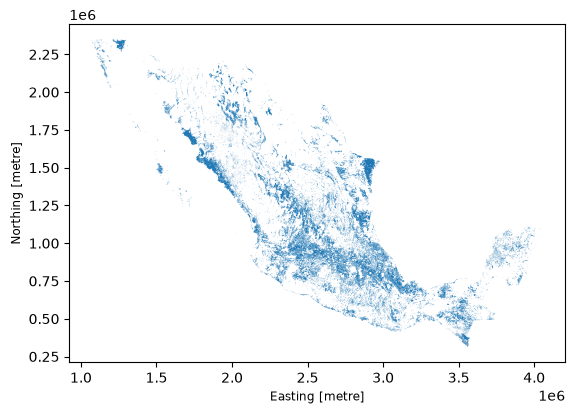

In [4]:
v = test['DESCRIPCIO'].unique()

ag = []
for k in v:
    if "AGR" in k:
        ag.append(k)


agro_map = test[test['DESCRIPCIO'].isin(ag)]

agro_map.plot()

In [5]:
agro_map

,CLAVE,DESCRIPCIO,geometry
38230,HA,AGRICULTURA DE HUMEDAD ANUAL,"POLYGON ((3088803.469 423003.312, 3088771.741 ..."
38231,HA,AGRICULTURA DE HUMEDAD ANUAL,"POLYGON ((3194335.928 555090.026, 3194452.732 ..."
38232,HA,AGRICULTURA DE HUMEDAD ANUAL,"POLYGON ((3255422.905 596486.191, 3255394.188 ..."
38233,HA,AGRICULTURA DE HUMEDAD ANUAL,"POLYGON ((3255270.72 594680.826, 3254799.032 5..."
38234,HA,AGRICULTURA DE HUMEDAD ANUAL,"POLYGON ((3254657.643 599566.929, 3254483.622 ..."
...,...,...,...
123840,TSP,AGRICULTURA DE TEMPORAL SEMIPERMANENTE Y PERMA...,"POLYGON ((2171382.466 1061442.055, 2171487.024..."
123841,TSP,AGRICULTURA DE TEMPORAL SEMIPERMANENTE Y PERMA...,"POLYGON ((2817250.362 1065407.968, 2817171.371..."
123842,TSP,AGRICULTURA DE TEMPORAL SEMIPERMANENTE Y PERMA...,"POLYGON ((2846715.249 1067029.961, 2846635.219..."
123843,TSP,AGRICULTURA DE TEMPORAL SEMIPERMANENTE Y PERMA...,"POLYGON ((2204435.926 1078602.259, 2204473.086..."


In [6]:
mex = gpd.read_file("../docs/mexico_agro/Mexico/conjunto_de_datos/00ent.shp")

<Axes: xlabel='Easting [metre]', ylabel='Northing [metre]'>

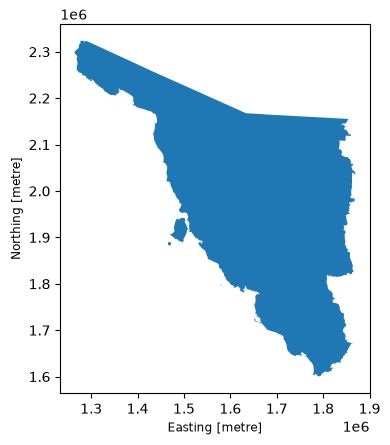

In [24]:
son = mex[mex['CVEGEO']=="26"]
son.plot()

In [30]:
agro_son=gpd.sjoin(agro_map, son, how="inner", predicate="within")

/tmp/ipykernel_82701/2617420314.py:1: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: PROJCS["Albers_Conic_Equal_Area",GEOGCS["GCS_GRS_1 ...
Right CRS: EPSG:6372

  agro_son=gpd.sjoin(agro_map, son, how="inner", predicate="within")


In [1]:
import yarl
from requests_html import AsyncHTMLSession
from bs4 import BeautifulSoup




/home/david/Documents/Repositories/academica/proyecto_agronomia/.venv/lib/python3.14/site-packages/websockets/protocol.py:1200: SyntaxWarning: 'return' in a 'finally' block
  return
/home/david/Documents/Repositories/academica/proyecto_agronomia/.venv/lib/python3.14/site-packages/websockets/protocol.py:1207: SyntaxWarning: 'return' in a 'finally' block
  return


In [2]:
session = AsyncHTMLSession()
url = yarl.URL("https://www.inegi.org.mx/temas/usosuelo/#descargas")
response = await session.get(url)

await response.html.arender()


: 

In [21]:
soup = BeautifulSoup(response.content, "lxml")

In [37]:
data = soup.find("body")
for q in data.find_all("div", recursive=False):
    print(q)
    print("______")

<div><!--Encabezado-->
<header>
<div data-english="1" data-tema="0" data-temselec="0" id="rootEncabezado"></div>
</header>
</div>
______
<div class="container mb-5"><!--Barra de navegación-->
<main><bnavegacion-inegi seccion="temas" titulo=""></bnavegacion-inegi><!--Titulo--><titulo-inegi texto=""></titulo-inegi>
<div class="row"><!--Menu lateral--><menu-gen class="col-lg-3 col-12" idm="204" tipo="0" url=""></menu-gen><!--Div del contenido principal-->
<div class="col-12 col-lg-9 ps-lg-0">
<div class="card">
<div class="card-body">
<!--Presentación--><presentacion-gen></presentacion-gen><!--Programas y temas relacionados--><relaciontp-gen idc="204" tipo="tema"></relaciontp-gen><!--Pestañas--><pestanas-gen></pestanas-gen>
</div>
</div>
</div>
</div>
</main>
</div>
______
<div id="PiePagina"></div>
______
